## Next GEMS data extraction

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator
import gribscan
import intake
import uxarray as ux
import healpy

In [2]:
def attach_coords(ds):
    model_lon = ds.lon.values
    model_lat = ds.lat.values
    return ds.assign_coords(
        lat = (("value",), model_lat, {"units": "degree_north"}),
        lon = (("value",), model_lon, {"units": "degree_east"}),
    )


def attach_depth_coords(ds):
    nz1  = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5,
    62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5, 105, 115, 125, 135, 145,
    155, 165, 175, 185, 195, 210, 230, 250, 270, 290, 320, 360, 400, 440,
    480, 520, 560, 600, 640, 710, 810, 950, 1110, 1255, 1415, 1600, 1810,
    2035, 2275, 2525, 2775, 3025, 3275, 3525, 3775, 4025, 4275, 4525, 4775,
    5025, 5275, 5525, 5825, 6175, 6175]
    nz = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
    90, 95, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 240,
    260, 280, 300, 340, 380, 420, 460, 500, 540, 580, 620, 660, 760, 860,
    1040, 1180, 1330, 1500, 1700, 1920, 2150, 2400, 2650, 2900, 3150, 3400,
    3650, 3900, 4150, 4400, 4650, 4900, 5150, 5400, 5650, 6000, 6350]
    return ds.assign_coords(
        nz1 = (("level",), nz1, {"units": "m"}),
        nz = (("level",), nz, {"units": "m"}),
    )

In [5]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
print(list(cat.FESOM))

['IFS_4.4-FESOM_5-cycle3', 'IFS_28-FESOM_25-cycle3', 'IFS_9-FESOM_5-cycle3', 'FESOM_13_tropo_age_interpolated']


In [9]:
print(list(cat))

['ICON', 'IFS', 'FESOM', 'ERA5', 'JRA3Q', 'MERRA2']


In [11]:
print(list(cat.FESOM['IFS_28-FESOM_25-cycle3'])) 

['2D_1h_native', '2D_daily_native', '2D_monthly_native', '3D_3h_native', '3D_daily_native', '3D_monthly_0.25deg', '3D_monthly_1deg', 'elem_grid', 'node_grid']


In [118]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="zarr.core.metadata.v2")
data = cat.IFS['IFS_9-FESOM_5-production']['3D_daily_healpix512_ocean'].to_dask().pipe(attach_coords)
data

<xarray.Dataset> Size: 95TB
Dimensions:     (time: 10816, level: 70, value: 3145728)
Coordinates:
  * time        (time) datetime64[ns] 87kB 2020-01-21 2020-01-22 ... 2050-01-01
  * level       (level) int64 560B 1 2 3 4 5 6 7 8 9 ... 63 64 65 66 67 68 69 70
    lon         (value) float64 25MB 45.0 45.09 44.91 45.0 ... 315.1 314.9 315.0
    lat         (value) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
Dimensions without coordinates: value
Data variables:
    avg_uoe     (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_wo      (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_von     (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_thetao  (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_so      (time, level, value) float64 19TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

In [96]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
ds = cat.ICON.ngc3028.to_dask()  # this does NOT use dask, see note below
ds

<xarray.Dataset> Size: 208MB
Dimensions:                              (time: 2010, depth_half: 129,
                                          cell: 12, level_full: 90, crs: 1,
                                          depth_full: 128,
                                          soil_depth_water_level: 5,
                                          level_half: 91,
                                          soil_depth_energy_level: 5)
Coordinates:
  * crs                                  (crs) float32 4B nan
  * depth_full                           (depth_full) float32 512B 1.0 ... 5....
  * depth_half                           (depth_half) float32 516B 0.0 ... 6....
  * level_full                           (level_full) int32 360B 1 2 3 ... 89 90
  * level_half                           (level_half) int32 364B 1 2 3 ... 90 91
  * soil_depth_energy_level              (soil_depth_energy_level) float32 20B ...
  * soil_depth_water_level               (soil_depth_water_level) float32 20B ...
  * time                                 (time) datetime64[ns] 16kB 2020-01-2...
    zg                                   (level_full, cell) float32 4kB ...
    zghalf                               (level_half, cell) float32 4kB ...
Dimensions without coordinates: cell
Data variables: (12/92)
    a_tracer_v_to                        (time, depth_half, cell) float32 12MB ...
    atmos_fluxes_frshflux_evaporation    (time, cell) float32 96kB ...
    atmos_fluxes_frshflux_precipitation  (time, cell) float32 96kB ...
    atmos_fluxes_frshflux_runoff         (time, cell) float32 96kB ...
    atmos_fluxes_frshflux_snowfall       (time, cell) float32 96kB ...
    atmos_fluxes_heatflux_latent         (time, cell) float32 96kB ...
    ...                                   ...
    va                                   (time, level_full, cell) float32 9MB ...
    vas                                  (time, cell) float32 96kB ...
    w                                    (time, depth_half, cell) float32 12MB ...
    wa_phy                               (time, level_half, cell) float32 9MB ...
    wind_speed_10m                       (time, cell) float32 96kB ...
    zos                                  (time, cell) float32 96kB ...

In [120]:
ds.crs

<xarray.DataArray 'crs' (crs: 1)> Size: 4B
array([nan], dtype=float32)
Coordinates:
  * crs      (crs) float32 4B nan
Attributes:
    grid_mapping_name:  healpix
    healpix_nside:      1
    healpix_order:      nest

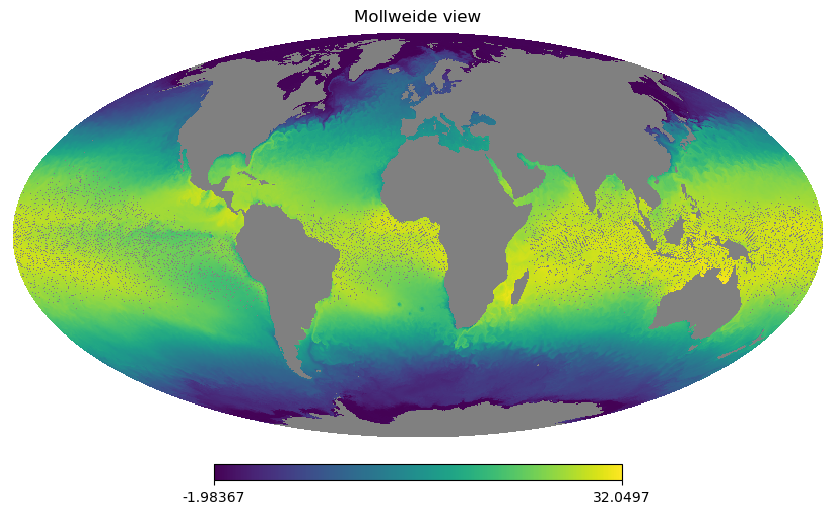

In [114]:
def get_nest(ds):
    return ds.crs.healpix_order == "nest"


healpy.mollview(data.isel(time=0,level=0).avg_thetao, flip="geo", nest=get_nest(ds))

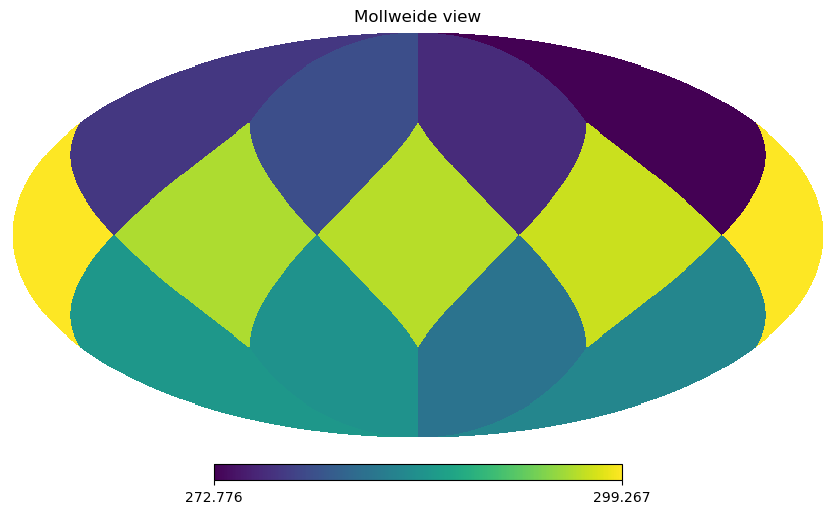

In [111]:
ds_map = cat.ICON.ngc3028(zoom=9).to_dask()
healpy.mollview(ds_map.tas.isel(time=0), flip="geo", nest=get_nest(ds_map))

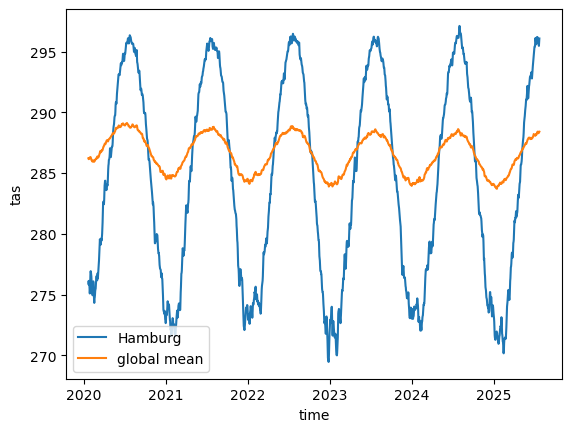

In [116]:
def get_nside(ds):
    return ds.crs.healpix_nside


model_run = cat.ICON.ngc3028

ds_fine = model_run(zoom=10).to_dask()
hamburg = healpy.ang2pix(
    get_nside(ds_fine), 9.993333, 53.550556, lonlat=True, nest=get_nest(ds_fine)
)

ds_fine.tas.isel(cell=hamburg).plot(label="Hamburg")
model_run(zoom=0).to_dask().tas.mean("cell").plot(label="global mean")
plt.legend()

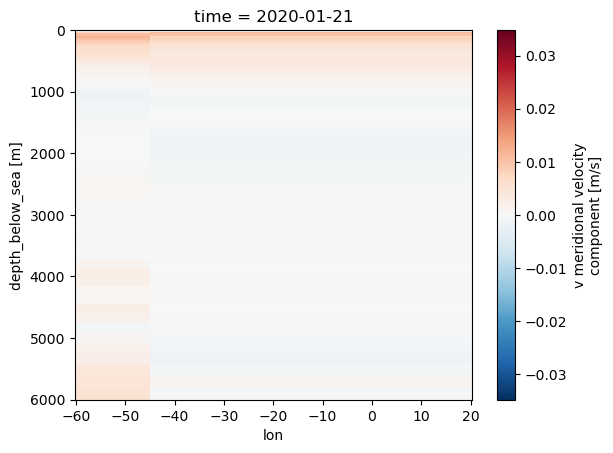

In [117]:
lons = np.linspace(-60.0, 20.0, 200)
lats = np.full_like(lons, 0.0)

ds = model_run(zoom=7).to_dask()

pnts = xr.DataArray(
    healpy.ang2pix(get_nside(ds), lons, lats, lonlat=True, nest=get_nest(ds)),
    dims=("cell",),
    coords={"lon": (("cell",), lons), "lat": (("cell",), lats)},
)

ds.v.isel(time=0, cell=pnts).swap_dims({"cell": "lon"}).plot(x="lon", yincrease=False)

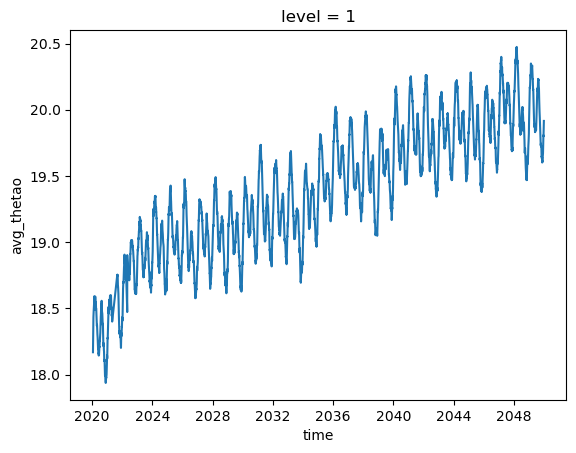

In [100]:
import pandas as pd
# pd.DataFrame(data.describe()["user_parameters"])
data.isel(level=0).avg_thetao.mean("value").plot()

In [8]:
ds = data.sel(time=slice('01-06-2022','01-07-2025'))
ds

<xarray.Dataset> Size: 10TB
Dimensions:     (time: 1098, level: 70, value: 3145728)
Coordinates:
  * time        (time) datetime64[ns] 9kB 2022-01-06 2022-01-07 ... 2025-01-07
  * level       (level) int64 560B 1 2 3 4 5 6 7 8 9 ... 63 64 65 66 67 68 69 70
    lon         (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    lat         (value) float64 25MB dask.array<chunksize=(3145728,), meta=np.ndarray>
    nz1         (level) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    nz          (level) int64 560B 0 5 10 15 20 25 ... 5150 5400 5650 6000 6350
Dimensions without coordinates: value
Data variables:
    avg_uoe     (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_wo      (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_von     (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_thetao  (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
    avg_so      (time, level, value) float64 2TB dask.array<chunksize=(1, 1, 3145728), meta=np.ndarray>
Attributes:
    edition:            2
    centre:             ecmf
    centreDescription:  European Centre for Medium-Range Weather Forecasts
    subCentre:          1003
    history:            🪄🧙‍♂️🔮 magic dataset assembly provided by gribscan.IF...

In [11]:
lon = ds.lon.compute()
lat = ds.lat.compute()

In [64]:
(lat.shift(value=-1) - lat.value)

<xarray.DataArray (value: 3145728)> Size: 25MB
array([ 1.49207928e-01, -8.50792072e-01, -1.77618779e+00, ...,
       -3.14572515e+06, -3.14572607e+06,             nan],
      shape=(3145728,))
Coordinates:
    lon      (value) float64 25MB 45.0 45.09 44.91 45.0 ... 315.1 314.9 315.0
    lat      (value) float64 25MB 0.0746 0.1492 0.1492 ... -0.1492 -0.0746
Dimensions without coordinates: value

In [91]:
# 1. Select one time/depth level
ds_subset = ds.isel(time=0, level=0)

# 2. Create Healpix grid
grid = ux.Grid.from_healpix(zoom=9)

# 3. Prepare dimension for uxarray
ds_subset = ds_subset.assign_coords(cell=("value", np.arange(ds_subset.sizes["value"])))
ds_subset = ds_subset.swap_dims({"value": "cell"})  # instead of rename_dims
ds_subset = ds_subset.rename({"lat": "face_lat", "lon": "face_lon"})

# 4. Convert to UxDataset
uxds = ux.UxDataset(source_datasets=ds_subset, uxgrid=grid)
uxds

<xarray.UxDataset> Size: 0B
Dimensions:  ()
Data variables:
    *empty*

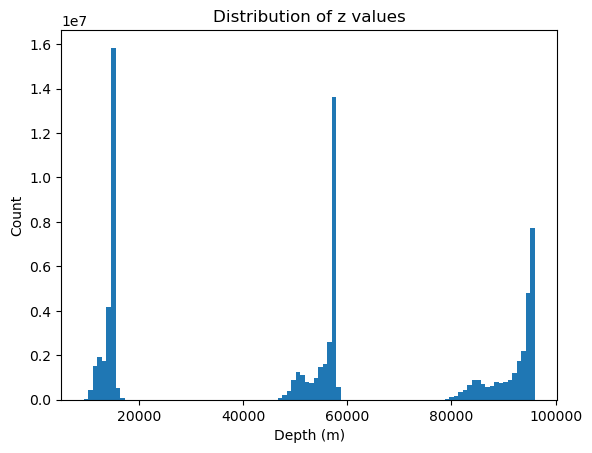

In [52]:
# For one time step and one level
zz = data.isel(time=0).z

import matplotlib.pyplot as plt
z_flat = zz.values.flatten()
plt.hist(z_flat[~np.isnan(z_flat)], bins=100)
plt.xlabel("Depth (m)")
plt.ylabel("Count")
plt.title("Distribution of z values")
plt.show()
# compute().data[()]

In [53]:
data.z.attrs

{'paramId': 129,
 'dataType': 'fc',
 'numberOfPoints': 26306560,
 'typeOfLevel': 'isobaricInhPa',
 'stepUnits': 1,
 'stepType': 'instant',
 'gridType': 'reduced_gg',
 'shortName': 'z',
 'units': 'm**2 s**-2',
 'name': 'Geopotential',
 'cfName': 'geopotential',
 'cfVarName': 'z',
 'missingValue': 3.4028234663852886e+38,
 'totalNumber': 0,
 'NV': 0,
 'gridDefinitionDescription': 'Gaussian Latitude/Longitude Grid'}